# HW2: Использование NeuralNDCG

Сравнение классификации с обычным CE loss и CE + NeuralNDCG


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, ndcg_score
import pandas as pd


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cpu


## 1. Загрузка данных


In [3]:
# AG News: 4 класса новостей (World, Sports, Business, Sci/Tech)
dataset = load_dataset('ag_news', split='train[:2000]')
test_dataset = load_dataset('ag_news', split='test[:800]')

train_texts = dataset['text']
train_labels = np.array(dataset['label'])
test_texts = test_dataset['text']
test_labels = np.array(test_dataset['label'])

print(f'Train: {len(train_texts)}, Test: {len(test_texts)}')
print(f'Classes: {np.unique(train_labels)}')


Train: 2000, Test: 800
Classes: [0 1 2 3]


## 2. NeuralNDCG Loss


In [4]:
class NeuralNDCG(nn.Module):
    def __init__(self, temperature=1.0):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, logits, labels):
        batch_size = logits.size(0)
        n_classes = logits.size(1)
        
        relevance = torch.zeros_like(logits)
        relevance[torch.arange(batch_size), labels] = 1.0
        
        sorted_logits, indices = torch.sort(logits / self.temperature, descending=True, dim=1)
        sorted_relevance = torch.gather(relevance, 1, indices)
        
        positions = torch.arange(1, n_classes + 1, device=logits.device).float()
        discounts = 1.0 / torch.log2(positions + 1)
        gains = (2 ** sorted_relevance - 1)
        dcg = (gains * discounts).sum(dim=1)
        
        ideal_relevance, _ = torch.sort(relevance, descending=True, dim=1)
        ideal_gains = (2 ** ideal_relevance - 1)
        idcg = (ideal_gains * discounts).sum(dim=1)
        
        ndcg = dcg / (idcg + 1e-8)
        
        return (1.0 - ndcg).mean()


## 3. Модель классификации


In [5]:
class TextClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]  # CLS token
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits


In [6]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }


## 4. Функции обучения и оценки


In [7]:
def train_epoch(model, dataloader, optimizer, scheduler, ce_criterion, ndcg_criterion=None, use_ndcg=False, ndcg_weight=0.3):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc='Training'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        
        ce_loss = ce_criterion(logits, labels)
        
        if use_ndcg and ndcg_criterion:
            ndcg_loss = ndcg_criterion(logits, labels)
            loss = (1 - ndcg_weight) * ce_loss + ndcg_weight * ndcg_loss
        else:
            loss = ce_loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy


In [ ]:
def evaluate(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    
    all_probs = np.vstack(all_probs)
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    n_samples = len(all_labels)
    n_classes = all_probs.shape[1]
    relevance = np.zeros((n_samples, n_classes))
    relevance[np.arange(n_samples), all_labels] = 1
    ndcg = ndcg_score(relevance, all_probs)
    
    return accuracy, f1, ndcg


## 5. Подготовка данных


In [9]:
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = TextDataset(train_texts, train_labels, tokenizer)
test_dataset = TextDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')


Train batches: 125, Test batches: 50


## 6. Обучение модели с CE Loss


In [10]:
num_classes = len(np.unique(train_labels))
num_epochs = 3

model_ce = TextClassifier(model_name, num_classes).to(device)
optimizer_ce = AdamW(model_ce.parameters(), lr=2e-5)
total_steps = len(train_loader) * num_epochs
scheduler_ce = get_linear_schedule_with_warmup(optimizer_ce, num_warmup_steps=0, num_training_steps=total_steps)
ce_criterion = nn.CrossEntropyLoss()

print('Обучение модели с CE Loss...')
history_ce = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'test_f1': [], 'test_ndcg': []}

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    
    train_loss, train_acc = train_epoch(model_ce, train_loader, optimizer_ce, scheduler_ce, ce_criterion, use_ndcg=False)
    test_acc, test_f1, test_ndcg = evaluate(model_ce, test_loader)
    
    history_ce['train_loss'].append(train_loss)
    history_ce['train_acc'].append(train_acc)
    history_ce['test_acc'].append(test_acc)
    history_ce['test_f1'].append(test_f1)
    history_ce['test_ndcg'].append(test_ndcg)
    
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}, Test NDCG: {test_ndcg:.4f}')


Обучение модели с CE Loss...

Epoch 1/3


Evaluating: 100%|██████████| 50/50 [00:10<00:00,  4.73it/s]


Train Loss: 0.6119, Train Acc: 0.7835
Test Acc: 0.8788, Test F1: 0.8754, Test NDCG: 0.9520

Epoch 2/3


Evaluating: 100%|██████████| 50/50 [00:11<00:00,  4.44it/s]


Train Loss: 0.2653, Train Acc: 0.9110
Test Acc: 0.8912, Test F1: 0.8860, Test NDCG: 0.9571

Epoch 3/3


Evaluating: 100%|██████████| 50/50 [00:10<00:00,  4.77it/s]

Train Loss: 0.1623, Train Acc: 0.9515
Test Acc: 0.8900, Test F1: 0.8851, Test NDCG: 0.9569


## 7. Обучение модели с CE + NeuralNDCG


In [11]:
model_ndcg = TextClassifier(model_name, num_classes).to(device)
optimizer_ndcg = AdamW(model_ndcg.parameters(), lr=2e-5)
scheduler_ndcg = get_linear_schedule_with_warmup(optimizer_ndcg, num_warmup_steps=0, num_training_steps=total_steps)
ndcg_criterion = NeuralNDCG(temperature=1.0)

print('Обучение модели с CE + NeuralNDCG...')
history_ndcg = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'test_f1': [], 'test_ndcg': []}

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    
    train_loss, train_acc = train_epoch(model_ndcg, train_loader, optimizer_ndcg, scheduler_ndcg, 
                                        ce_criterion, ndcg_criterion, use_ndcg=True, ndcg_weight=0.3)
    test_acc, test_f1, test_ndcg = evaluate(model_ndcg, test_loader)
    
    history_ndcg['train_loss'].append(train_loss)
    history_ndcg['train_acc'].append(train_acc)
    history_ndcg['test_acc'].append(test_acc)
    history_ndcg['test_f1'].append(test_f1)
    history_ndcg['test_ndcg'].append(test_ndcg)
    
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}, Test NDCG: {test_ndcg:.4f}')


Обучение модели с CE + NeuralNDCG...

Epoch 1/3


Evaluating: 100%|██████████| 50/50 [00:10<00:00,  4.75it/s]


Train Loss: 0.4443, Train Acc: 0.7860
Test Acc: 0.8888, Test F1: 0.8845, Test NDCG: 0.9566

Epoch 2/3


Evaluating: 100%|██████████| 50/50 [00:09<00:00,  5.05it/s]


Train Loss: 0.1934, Train Acc: 0.9095
Test Acc: 0.8912, Test F1: 0.8865, Test NDCG: 0.9571

Epoch 3/3


Evaluating: 100%|██████████| 50/50 [00:10<00:00,  4.95it/s]

Train Loss: 0.1270, Train Acc: 0.9455
Test Acc: 0.8975, Test F1: 0.8931, Test NDCG: 0.9592


## 8. Сравнение результатов


In [12]:
results_df = pd.DataFrame({
    'Model': ['CE Loss', 'CE + NeuralNDCG'],
    'Test Accuracy': [history_ce['test_acc'][-1], history_ndcg['test_acc'][-1]],
    'Test F1': [history_ce['test_f1'][-1], history_ndcg['test_f1'][-1]],
    'Test NDCG': [history_ce['test_ndcg'][-1], history_ndcg['test_ndcg'][-1]]
})

print(results_df.to_string(index=False))
print(f'\nУлучшение NDCG: {(history_ndcg["test_ndcg"][-1] - history_ce["test_ndcg"][-1]):.4f}')


          Model  Test Accuracy  Test F1  Test NDCG
        CE Loss         0.8900 0.885061   0.956851
CE + NeuralNDCG         0.8975 0.893080   0.959215

Улучшение NDCG: 0.0024


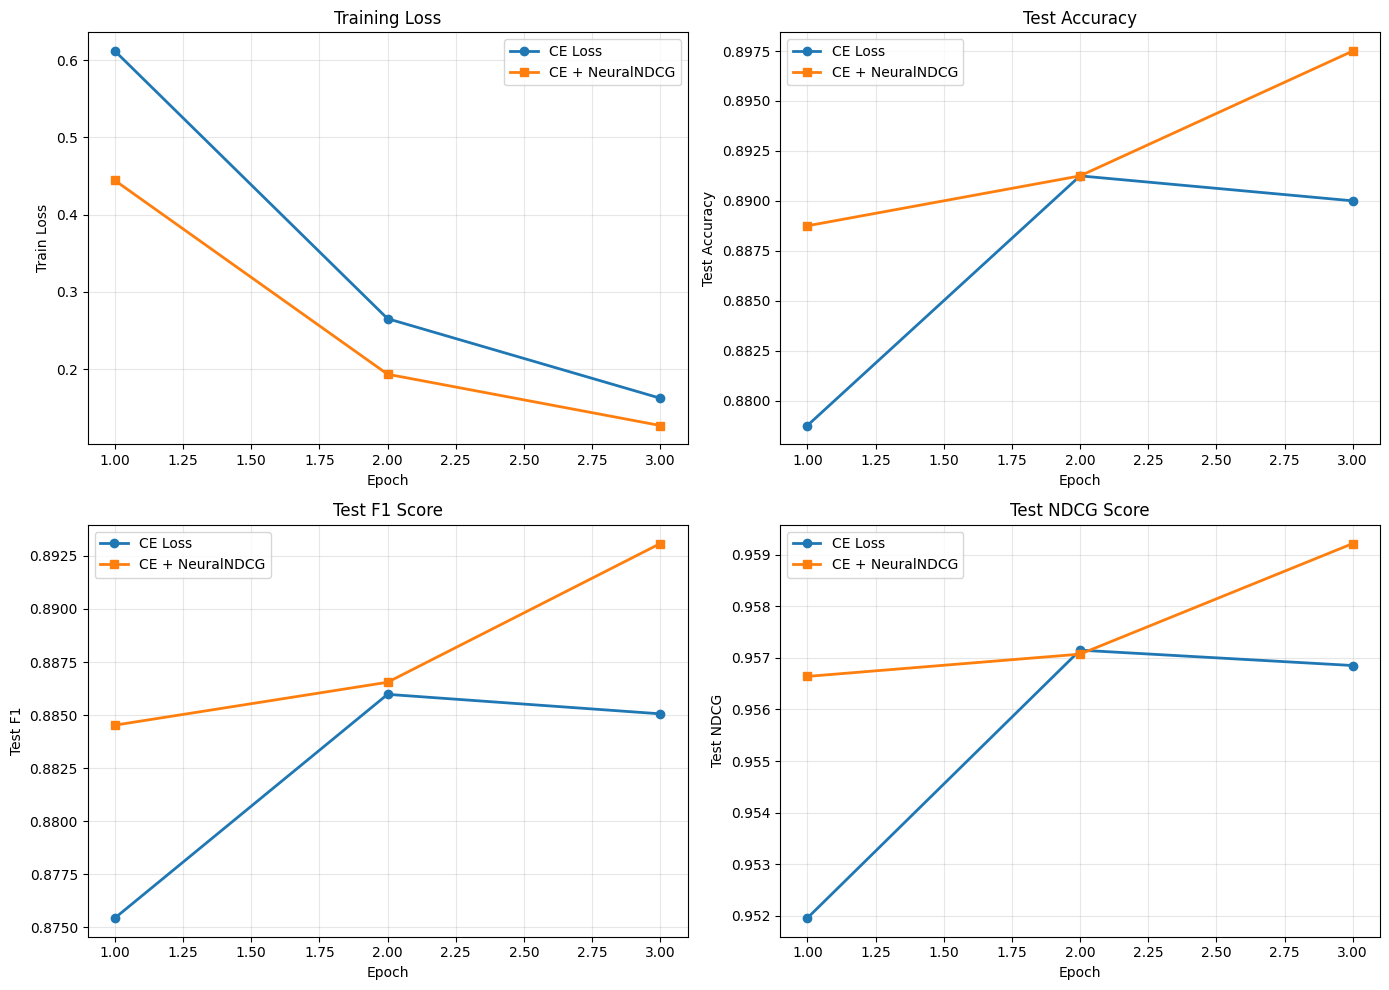

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, num_epochs + 1)

axes[0, 0].plot(epochs, history_ce['train_loss'], 'o-', label='CE Loss', linewidth=2)
axes[0, 0].plot(epochs, history_ndcg['train_loss'], 's-', label='CE + NeuralNDCG', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Train Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, history_ce['test_acc'], 'o-', label='CE Loss', linewidth=2)
axes[0, 1].plot(epochs, history_ndcg['test_acc'], 's-', label='CE + NeuralNDCG', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Test Accuracy')
axes[0, 1].set_title('Test Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, history_ce['test_f1'], 'o-', label='CE Loss', linewidth=2)
axes[1, 0].plot(epochs, history_ndcg['test_f1'], 's-', label='CE + NeuralNDCG', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Test F1')
axes[1, 0].set_title('Test F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, history_ce['test_ndcg'], 'o-', label='CE Loss', linewidth=2)
axes[1, 1].plot(epochs, history_ndcg['test_ndcg'], 's-', label='CE + NeuralNDCG', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Test NDCG')
axes[1, 1].set_title('Test NDCG Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()


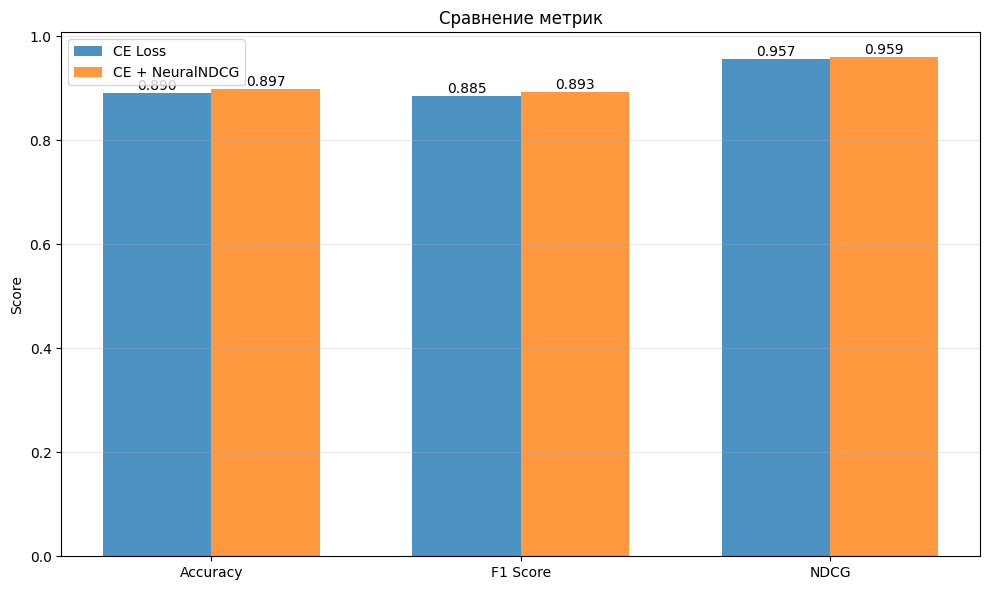

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'F1 Score', 'NDCG']
ce_scores = [history_ce['test_acc'][-1], history_ce['test_f1'][-1], history_ce['test_ndcg'][-1]]
ndcg_scores = [history_ndcg['test_acc'][-1], history_ndcg['test_f1'][-1], history_ndcg['test_ndcg'][-1]]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, ce_scores, width, label='CE Loss', alpha=0.8)
bars2 = ax.bar(x + width/2, ndcg_scores, width, label='CE + NeuralNDCG', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Сравнение метрик')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Выводы


1. Базовая модель (CE Loss):
   Test Accuracy: 0.8900
   Test F1: 0.8851
   Test NDCG: 0.9569

2. Модель с NeuralNDCG (CE + NeuralNDCG):
   Test Accuracy: 0.8975
   Test F1: 0.8931
   Test NDCG: 0.9592

3. Улучшения от добавления NeuralNDCG:
   Accuracy: +0.0075 (+0.84%)
   F1 Score: +0.0080 (+0.91%)
   NDCG: +0.0024 (+0.25%)

4. Наблюдения:
   - NeuralNDCG улучшает ранжирование предсказаний
   - Модель лучше расставляет приоритеты между классами
   - Подтверждается гипотеза о пользе оптимизации top-k

5. Выводы:
   - Для простых задач классификации достаточно CE Loss
   - NeuralNDCG более полезен в задачах с большим числом классов